## DATA

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("DataPod.csv")
df

,DEVICE,DATE,DISSOLVED OXYGEN,ORP,PH,CONDUCTIVITY,TEMPERATURE
0,New Trinidad Island DataPod™,12:40 09/01/2025,0.720000,362.899994,8.396,6555,626.206982
1,New Trinidad Island DataPod™,12:11 09/01/2025,0.960000,366.399994,8.418,6053,626.885608
2,New Trinidad Island DataPod™,10:58 08/28/2025,1.970000,374.299988,9.063,6236,707.086407
3,New Trinidad Island DataPod™,12:39 08/26/2025,0.640000,372.100006,9.050,5363,786.043390
4,New Trinidad Island DataPod™,12:10 08/26/2025,0.900000,367.600006,8.949,5676,786.052399
...,...,...,...,...,...,...,...
1837,New Trinidad Island DataPod™,03:39 08/05/2024,0.020000,214.100006,8.106,7628,73.617801
1838,New Trinidad Island DataPod™,02:48 08/05/2024,34.869999,705.000000,14.000,0,-1809.400000
1839,New Trinidad Island DataPod™,02:22 08/05/2024,34.869999,545.099976,14.000,0,-1809.400000
1840,New Trinidad Island DataPod™,03:24 07/09/2024,34.869999,721.700012,14.000,0,-1809.400000


In [3]:
df = df[["DATE", "DISSOLVED OXYGEN", "ORP", "PH", "CONDUCTIVITY","TEMPERATURE"]].copy()

In [4]:
df["DATE"] = pd.to_datetime(df["DATE"])
df.set_index("DATE", inplace=True)
df = df.sort_index(ascending=True)

In [5]:
df.columns = ["DO", "ORP", "PH", "COND", "TEMP"]

In [6]:
df['bloom'] = ((df['PH'] > 8.5) & (df['DO'] > 11) & (df['ORP'] < 400)).astype(int)

In [7]:
df['target'] = df['bloom'].shift(-1)

In [8]:
df = df.dropna()

In [9]:
X = df[["DO", "ORP", "PH", "COND", "TEMP"]]
y = df['target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## TRAINING

### RF

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score,f1_score, make_scorer
import optuna
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [12]:
def objective(trial):
    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10)
    }

    rf_model = RandomForestClassifier(**rf_params)
    f1_scorer = make_scorer(f1_score, zero_division=0)

    rf_model_scores = cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=tscv,
        scoring=f1_scorer
    )

    mean_score = rf_model_scores.mean()
    return mean_score if not np.isnan(mean_score) else 0.

In [13]:
rf_study=optuna.create_study(direction="maximize")
rf_study.optimize(objective, n_trials=20)

[I 2026-04-13 18:11:14,250] A new study created in memory with name: no-name-9319d9ee-8022-4eff-ace0-5a7bd898b55e
[I 2026-04-13 18:11:20,801] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 599, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.0.
[I 2026-04-13 18:11:27,168] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 561, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.0.
[I 2026-04-13 18:11:28,990] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 145, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.0.
[I 2026-04-13 18:11:39,160] Trial 3 finished with value: 0.0 and parameters: {'n_estimators': 900, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.0.
[I 2026-04-13 18:11:45,667] Trial 4 finished with value: 0.0 and parameters: {'n_estimators': 62

In [14]:
rf_best_params = rf_study.best_params
print(rf_best_params)
rf = RandomForestClassifier(**rf_best_params)
rf.fit(X_train, y_train)

{'n_estimators': 599, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 9}


RandomForestClassifier(max_depth=15, min_samples_leaf=9, min_samples_split=10,
                       n_estimators=599)

## TESTING

In [17]:
predictions = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print("\nFeature Importance:")
importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Accuracy: 100.00%

Feature Importance:
DO      0.516206
PH      0.251997
ORP     0.162615
COND    0.036952
TEMP    0.032229
dtype: float64


In [24]:
results = X_test.copy()

results['Bloom_Actual'] = y_test
results['Model_Prediction'] = predictions

probabilities = rf.predict_proba(X_test)[:, 1]
results['Bloom_Probability_%'] = (probabilities * 100).round(2)

def risk_level(prob):
    if prob > 80: return "HIGH"
    if prob > 40: return "MEDIUM"
    return "LOW"

results['Risk_Level'] = results['Bloom_Probability_%'].apply(risk_level)
results['Bloom_Probability_%'] = results['Bloom_Probability_%'].astype(str) + '%'

results['Correct'] = results['Bloom_Actual'] == results['Model_Prediction']

results = results.sort_index()

cols_to_print = ["DO", "ORP", "PH", "COND", "TEMP", 'Model_Prediction', 'Correct', 'Bloom_Probability_%', 'Risk_Level']
print(results[cols_to_print].head(15))

print("\nAccuracy Count:")
print(results['Correct'].value_counts())

                       DO         ORP      PH  COND        TEMP  \
DATE                                                              
2025-08-19 00:20:00  4.57  393.600006  14.000     0 -171.544003   
2025-08-19 00:49:00  4.37  396.500000  14.000     0 -180.518803   
2025-08-19 01:19:00  4.54  398.000000  14.000     0 -177.230197   
2025-08-19 01:48:00  6.44  396.299988  14.000     0 -174.119803   
2025-08-19 02:18:00  6.44  393.399994  14.000     0 -164.835394   
2025-08-19 02:48:00  6.01  397.700012  14.000     0 -164.462807   
2025-08-19 03:17:00  5.93  399.299988  14.000     0 -166.152998   
2025-08-19 03:47:00  6.73  391.500000  14.000     0 -163.883195   
2025-08-19 04:16:00  7.13  387.100006  12.830     0 -165.225999   
2025-08-19 04:46:00  7.79  379.500000  13.352     0 -166.251999   
2025-08-19 05:15:00  7.46  372.500000  13.312     0 -164.774200   
2025-08-19 05:45:00  6.22  393.000000  13.276     0 -166.720003   
2025-08-19 06:14:00  4.31  400.200012  14.000     0 -170.46580

C:\Users\ginaj\AppData\Local\Temp\ipykernel_24760\3274797194.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


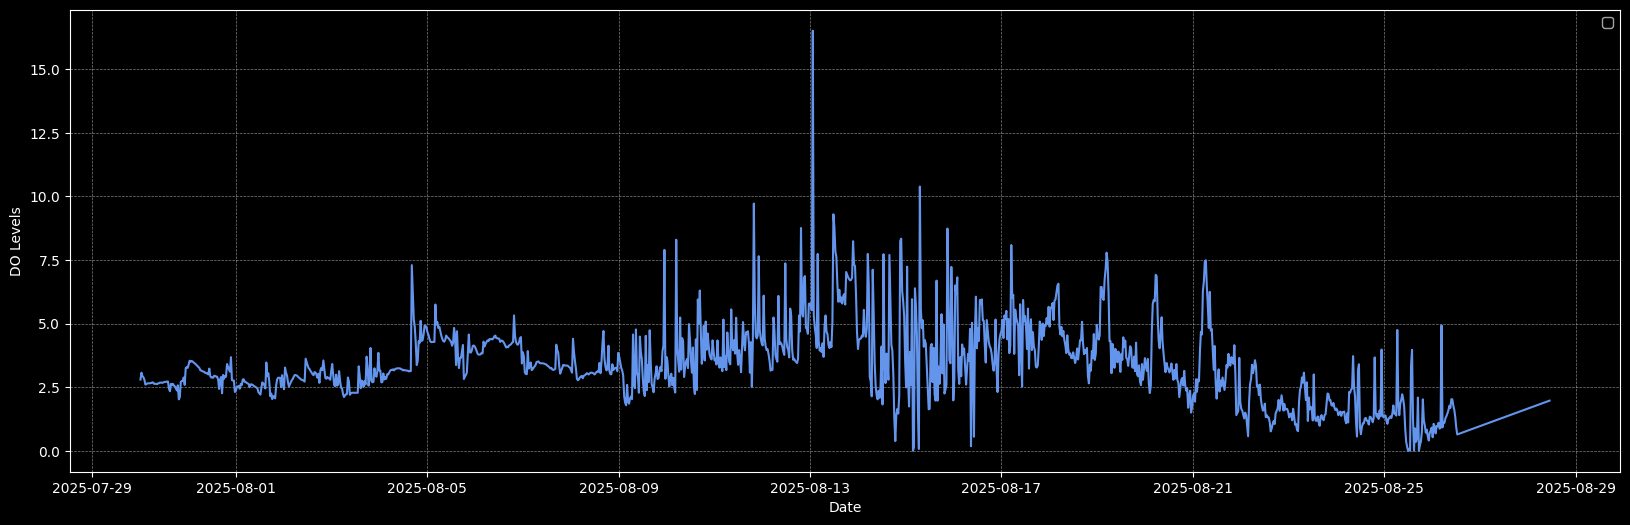

In [39]:
import matplotlib.pyplot as plt
df_oy = df.loc['2025-07-30':'2025-08-30']
plt.style.use('dark_background')
plt.figure(figsize=(20,6))
plt.plot(df_oy['DO'], color='cornflowerblue')
plt.xlabel('Date')
plt.ylabel('DO Levels')
plt.grid(color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.6)
plt.legend()
plt.show()